In [1]:
import pandas as pd
import geopandas as gpd

import numpy as np
import re

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
mzn = gpd.read_file('C:/Users/COMIMSA/Desktop/SECTEI/CDITVallejo/datos/00_insumos/manzanas_zonaestudio.gpkg')
print(mzn.shape)
mzn.head(1)

(6857, 263)


,CVEGEO,POB1,POB2,POB2_R,POB4,POB4_R,POB5,POB5_R,POB6,POB6_R,...,POB122_R,POB123,POB123_R,POB124,POB124_R,OID,layer,path,entorno,geometry
0,1505700011489032,0.0,-8.0,-8.0,-8.0,-8.0,-8.0,-8.0,-8.0,-8.0,...,-8.0,-8.0,-8.0,-8.0,-8.0,56962,manzana,C:\SCINCE 2020\SCINCE 2020\15_MEX\cartografia\...,Intermunicipal,"MULTIPOLYGON (((476610.482 2152824.118, 476507..."


In [2]:
descrip = pd.read_excel('C:/Users/COMIMSA/Desktop/SECTEI/CDITVallejo/datos/Descriptores_2020.xlsx')
descrip.head(1)

,CAMPO,DESCRIP
0,POB1,Población total


In [4]:

# --- Identificar columnas de grupos de edad por sexo ---
# En SCINCE 2020, los valores -8 indican dato no disponible/confidencial

mask_edad    = descrip['DESCRIP'].str.contains(r'\d+\s*(a|á)\s+\d+\s*años', case=False, na=False, regex=True)
mask_hombre  = descrip['DESCRIP'].str.contains(r'hombre|masculin', case=False, na=False)
mask_mujer   = descrip['DESCRIP'].str.contains(r'mujer|femenin', case=False, na=False)

# Excluir columnas _R (ratio/porcentaje)
mask_no_ratio = ~descrip['CAMPO'].str.endswith('_R')

hombres_df = descrip[mask_edad & mask_hombre & mask_no_ratio].copy()
mujeres_df = descrip[mask_edad & mask_mujer  & mask_no_ratio].copy()

print(f"Columnas de hombres por edad encontradas: {len(hombres_df)}")
print(hombres_df[['CAMPO', 'DESCRIP']].to_string(index=False))
print(f"\nColumnas de mujeres por edad encontradas: {len(mujeres_df)}")
print(mujeres_df[['CAMPO', 'DESCRIP']].to_string(index=False))


Columnas de hombres por edad encontradas: 41
  CAMPO                                                                        DESCRIP
  POB85                                              Población masculina de 0 a 2 años
  POB86                                              Población masculina de 0 a 4 años
  POB87                                              Población masculina de 3 a 5 años
  POB88                                             Población masculina de 6 a 11 años
  POB89                                             Población masculina de 8 a 14 años
  POB90                                            Población masculina de 12 a 14 años
  POB91                                             Población masculina de 0 a 14 años
  POB92                                            Población masculina de 15 a 17 años
  POB93                                            Población masculina de 15 a 24 años
  POB94                                            Población masculina de 15 a 29 año

C:\Users\COMIMSA\AppData\Local\Temp\ipykernel_12900\2253270800.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_edad    = descrip['DESCRIP'].str.contains(r'\d+\s*(a|á)\s+\d+\s*años', case=False, na=False, regex=True)


In [5]:

# --- Explorar TODOS los grupos de edad disponibles en el catálogo ---
# (sin filtro de sexo, para ver qué grupos exactos existen)

mask_edad_todos = (
    descrip['DESCRIP'].str.contains(r'\d+\s*(a|á)\s+\d+\s*años', case=False, na=False, regex=True)
    & ~descrip['CAMPO'].str.endswith('_R')
)

edad_todos = descrip[mask_edad_todos][['CAMPO', 'DESCRIP']].copy()
print(f"Total de columnas con grupos de edad: {len(edad_todos)}\n")
print(edad_todos.to_string(index=False))

Total de columnas con grupos de edad: 130

  CAMPO                                                                        DESCRIP
   POB2                                                        Población de 0 a 2 años
   POB3                                                        Población de 0 a 4 años
   POB4                                                        Población de 3 a 5 años
   POB5                                                       Población de 6 a 11 años
   POB6                                                       Población de 8 a 14 años
   POB7                                                      Población de 12 a 14 años
   POB8                                                       Población de 0 a 14 años
   POB9                                                      Población de 15 a 17 años
  POB10                                                      Población de 15 a 24 años
  POB11                                                      Población de 15 a 29 años


C:\Users\COMIMSA\AppData\Local\Temp\ipykernel_12900\1261519495.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  descrip['DESCRIP'].str.contains(r'\d+\s*(a|á)\s+\d+\s*años', case=False, na=False, regex=True)


In [6]:

# --- Seleccionar columnas de interés por grupos de edad ---
# Grupos objetivo: 0-2, 3-5, 6-11, 12-14, 15-17, 18-24, 25-29(*), 30-49, 50-59,
#                  60-64, 65-69, 70-74, 75-79, 80-84
# (*) 25-29 puede requerir cálculo si no existe directamente

def buscar_col(patron, sexo=None):
    """Devuelve la(s) columna(s) POB* que coincidan con el patrón de edad y sexo."""
    m = descrip['DESCRIP'].str.contains(patron, case=False, na=False, regex=True)
    m &= ~descrip['CAMPO'].str.endswith('_R')
    m &= descrip['CAMPO'].str.startswith('POB')   # ← solo variables de población pura
    if sexo == 'h':
        m &= descrip['DESCRIP'].str.contains(r'hombre|masculin', case=False, na=False)
    elif sexo == 'f':
        m &= descrip['DESCRIP'].str.contains(r'mujer|femenin', case=False, na=False)
    return descrip[m]['CAMPO'].tolist()

# Grupos con columnas directas (patrón rango exacto)
grupos_directos = {
    '0-2' :  r'0\s*(?:a|á)\s+2\s*años',
    '3-5' :  r'3\s*(?:a|á)\s+5\s*años',
    '6-11':  r'6\s*(?:a|á)\s+11\s*años',
    '12-14': r'12\s*(?:a|á)\s+14\s*años',
    '15-17': r'15\s*(?:a|á)\s+17\s*años',
    '18-24': r'18\s*(?:a|á)\s+24\s*años',
    '30-49': r'30\s*(?:a|á)\s+49\s*años',
    '50-59': r'50\s*(?:a|á)\s+59\s*años',
    '60-64': r'60\s*(?:a|á)\s+64\s*años',
    '65-69': r'65\s*(?:a|á)\s+69\s*años',
    '70-74': r'70\s*(?:a|á)\s+74\s*años',
    '75-79': r'75\s*(?:a|á)\s+79\s*años',
    '80-84': r'80\s*(?:a|á)\s+84\s*años',
}

print("=== Columnas directas encontradas ===")
cols_hombres = {}
cols_mujeres = {}
for grupo, patron in grupos_directos.items():
    ch = buscar_col(patron, sexo='h')
    cm = buscar_col(patron, sexo='f')
    estado = "OK" if (ch and cm) else "FALTA"
    print(f"  [{estado}] {grupo:6s}  H: {ch}  M: {cm}")
    cols_hombres[grupo] = ch[0] if ch else None
    cols_mujeres[grupo] = cm[0] if cm else None

# --- Estrategia para 25-29 (columna directa o diferencia) ---
print("\n=== Estrategia para grupo 25-29 ===")
for sexo, label in [('h', 'H'), ('f', 'M')]:
    directo = buscar_col(r'25\s*(?:a|á)\s+29\s*años', sexo=sexo)
    if directo:
        print(f"  [{label}] Directa: {directo[0]}")
        (cols_hombres if sexo == 'h' else cols_mujeres)['25-29'] = directo[0]
    else:
        c_2029 = buscar_col(r'20\s*(?:a|á)\s+29\s*años', sexo=sexo)
        c_2024 = buscar_col(r'20\s*(?:a|á)\s+24\s*años', sexo=sexo)
        if c_2029 and c_2024:
            print(f"  [{label}] 20-29 − 20-24: {c_2029[0]} − {c_2024[0]}")
            (cols_hombres if sexo == 'h' else cols_mujeres)['25-29'] = (c_2029[0], c_2024[0])
        else:
            print(f"  [{label}] Sin columna para 25-29. Revisar catálogo.")
            (cols_hombres if sexo == 'h' else cols_mujeres)['25-29'] = None

print("\ncols_hombres:", cols_hombres)
print("cols_mujeres:", cols_mujeres)


=== Columnas directas encontradas ===
  [OK] 0-2     H: ['POB85']  M: ['POB43']
  [OK] 3-5     H: ['POB87']  M: ['POB45']
  [OK] 6-11    H: ['POB88']  M: ['POB46']
  [OK] 12-14   H: ['POB90']  M: ['POB48']
  [OK] 15-17   H: ['POB92']  M: ['POB50']
  [OK] 18-24   H: ['POB96']  M: ['POB55']
  [OK] 30-49   H: ['POB97']  M: ['POB56']
  [OK] 50-59   H: ['POB98']  M: ['POB57']
  [OK] 60-64   H: ['POB99']  M: ['POB58']
  [OK] 65-69   H: ['POB120']  M: ['POB79']
  [OK] 70-74   H: ['POB121']  M: ['POB80']
  [OK] 75-79   H: ['POB122']  M: ['POB81']
  [OK] 80-84   H: ['POB123']  M: ['POB82']

=== Estrategia para grupo 25-29 ===
  [H] Directa: POB113
  [M] Directa: POB72

cols_hombres: {'0-2': 'POB85', '3-5': 'POB87', '6-11': 'POB88', '12-14': 'POB90', '15-17': 'POB92', '18-24': 'POB96', '30-49': 'POB97', '50-59': 'POB98', '60-64': 'POB99', '65-69': 'POB120', '70-74': 'POB121', '75-79': 'POB122', '80-84': 'POB123', '25-29': 'POB113'}
cols_mujeres: {'0-2': 'POB43', '3-5': 'POB45', '6-11': 'POB46', 

In [7]:

# --- Preparar datos para la pirámide ---

# Reemplazar -8 (no disponible) y -6 (confidencial) por NaN antes de sumar
mzn_clean = mzn.replace([-8, -6], np.nan)

orden_grupos = ['0-2', '3-5', '6-11', '12-14', '15-17', '18-24', '25-29',
                '30-49', '50-59', '60-64', '65-69', '70-74', '75-79', '80-84']


In [8]:

def sumar_col(mzn_df, entrada):
    """Suma una columna o calcula la diferencia de dos (caso 25-29 por resta)."""
    if entrada is None:
        return 0
    if isinstance(entrada, tuple):          # diferencia: (col_minuendo, col_sustraendo)
        return mzn_df[entrada[0]].sum() - mzn_df[entrada[1]].sum()
    return mzn_df[entrada].sum()            # columna directa

In [9]:
local = mzn_clean[mzn['entorno']=='Local']
barrio = mzn_clean[mzn['entorno']=='Barrio']
intermunicipal = mzn_clean[mzn['entorno']=='Intermunicipal']

print(mzn_clean.shape)
print(local.shape)
print(barrio.shape)
print(intermunicipal.shape)

(6857, 263)
(102, 263)
(494, 263)
(6261, 263)


# Local

In [12]:

# =============================================================
# CONFIGURACIÓN — ajusta aquí para cambiar todas las gráficas
# =============================================================
FIGSIZE   = (5, 7)       # (ancho, alto) en pulgadas
FONTSIZE  = 7            # tamaño base de letra
COLOR_H   = '#2196F3'    # color barras hombres
COLOR_M   = '#E91E63'    # color barras mujeres
DPI       = 150          # resolución de la imagen exportada

# =============================================================

def calcular_totales(df):
    """Agrega población por grupo de edad y sexo para un subconjunto de manzanas."""
    records_h, records_m = [], []
    for grupo in orden_grupos:
        records_h.append({'grupo': grupo, 'TOTAL': sumar_col(df, cols_hombres.get(grupo))})
        records_m.append({'grupo': grupo, 'TOTAL': sumar_col(df, cols_mujeres.get(grupo))})
    return pd.DataFrame(records_h), pd.DataFrame(records_m)


def graficar_piramide(totales_h, totales_m, titulo, archivo):
    """Genera y guarda una pirámide poblacional."""
    grupos = totales_h['grupo'].tolist()
    vals_h = totales_h['TOTAL'].values
    vals_m = totales_m['TOTAL'].values
    total  = vals_h.sum() + vals_m.sum()
    y      = np.arange(len(grupos))

    fig, ax = plt.subplots(figsize=FIGSIZE)

    ax.barh(y, -vals_h, height=0.75, color=COLOR_H, label='Hombres', zorder=2)
    ax.barh(y,  vals_m, height=0.75, color=COLOR_M, label='Mujeres',  zorder=2)

    offset = total * 0.002
    for i, (vh, vm) in enumerate(zip(vals_h, vals_m)):
        ax.text(-vh - offset, i, f'{int(vh):,}', va='center', ha='right',
                fontsize=FONTSIZE - 1.5, color='#1565C0')
        ax.text( vm + offset, i, f'{int(vm):,}', va='center', ha='left',
                fontsize=FONTSIZE - 1.5, color='#880E4F')

    ax.axvline(0, color='black', linewidth=1, zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels(grupos, fontsize=FONTSIZE)
    ax.set_ylabel('Grupo de edad', fontsize=FONTSIZE + 1)

    max_val = max(vals_h.max(), vals_m.max()) * 1.18
    ax.set_xlim(-max_val, max_val)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{abs(int(x)):,}'))
    ax.set_xlabel('Población', fontsize=FONTSIZE + 1)

    ax.xaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
    ax.set_axisbelow(True)

    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.12), ncol=2,
              fontsize=FONTSIZE + 1, frameon=False)
    ax.set_title(
        f'{titulo}\n'
        f'Población total: {int(total):,}  |  '
        f'Hombres: {int(vals_h.sum()):,}  |  Mujeres: {int(vals_m.sum()):,}',
        fontsize=FONTSIZE + 2, pad=12
    )

    plt.tight_layout()
    plt.savefig(archivo, dpi=DPI, bbox_inches='tight')
    plt.show()
    print(f"Guardado: '{archivo}'")


# Local

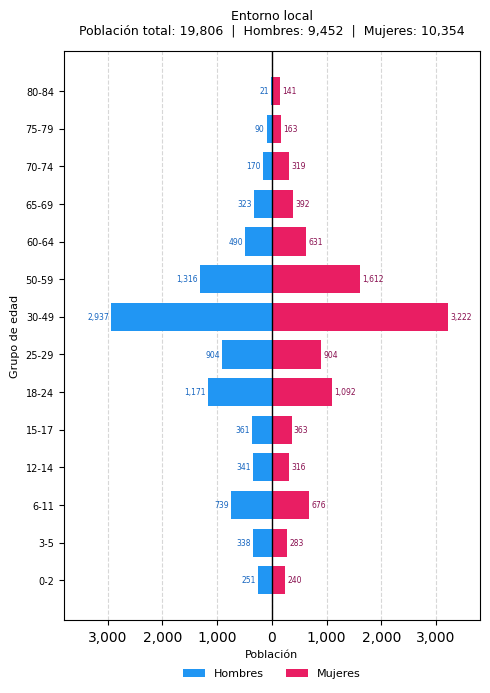

Guardado: 'piramide_poblacional_local.png'


In [15]:

totales_h, totales_m = calcular_totales(local)
graficar_piramide(totales_h, totales_m,
                  titulo='Entorno local',
                  archivo='piramide_poblacional_local.png')


# Barrio

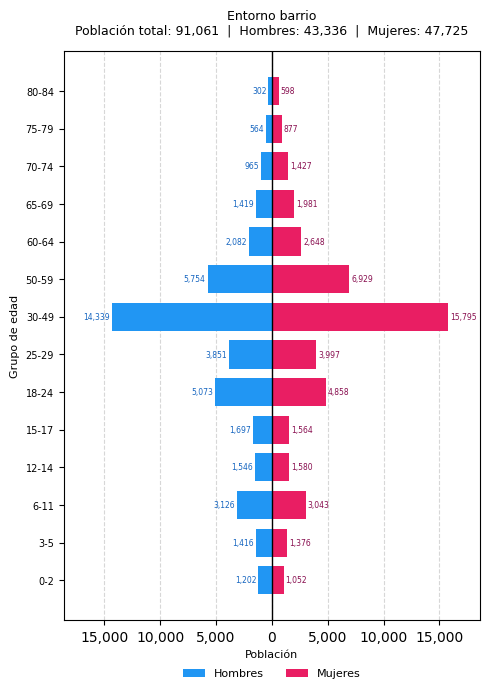

Guardado: 'piramide_poblacional_barrio.png'


In [16]:

totales_h, totales_m = calcular_totales(barrio)
graficar_piramide(totales_h, totales_m,
                  titulo='Entorno barrio',
                  archivo='piramide_poblacional_barrio.png')


# Intermunicipal

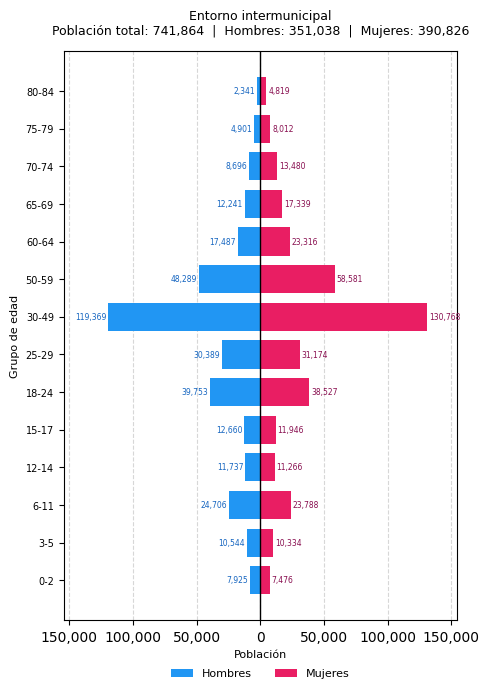

Guardado: 'piramide_poblacional_intermunicipal.png'


In [17]:

totales_h, totales_m = calcular_totales(intermunicipal)
graficar_piramide(totales_h, totales_m,
                  titulo='Entorno intermunicipal',
                  archivo='piramide_poblacional_intermunicipal.png')
